# ISW Text Features — EDA & Feature Engineering

Implements `PLAN_TEXT_FEATURES.md` Phases 3 and 4 for the **ISW** source only. Phases 1, 2, 4 for **Telegram** were already prototyped in `eda/eda_telegram_text_features.ipynb`, which explicitly scoped ISW out ("separate task per the plan").

**Diagnosed problems (from the plan):**
- Problem #6: `isw_features.py` already has a decent unsupervised pipeline (TF-IDF + KMeans + PCA + windowed drift/anomaly stats), but — like Telegram — it broadcasts the same national signal to all regions with no regional tie, and has no semantic embedding layer.
- Problem #1 (ISW half): `merge_data.py` merges ISW by `date` only, national-broadcast to all 25+ regions.

**Objective:** build and validate, in-notebook, the additive fixes:
1. `tag_regions(text)` for ISW's **English** text — analogous gazetteer to the Telegram notebook's uk/ru version, so ISW mentions can be merged on `(region_id, date)` instead of `date` alone.
2. Refactor the existing windowed feature block (`news_count`, `avg_dist_centroid`, `topic_entropy`, `dom_cluster_share`, `news_velocity`, `centroid_shift`, `anomaly_count`) into a function parameterized by an arbitrary feature matrix + cluster labels, and validate it reproduces the current production TF-IDF-based columns exactly.
3. Call that function a second time on multilingual sentence embeddings, producing an additive `isw_emb_*` block.

**Success criteria:** region columns fire only on dates that actually mention a region (cross-checked against real regional alarms), the refactored window function is numerically identical to production on the existing PCA/cluster columns, and `isw_emb_*` visibly separates high-mention from quiet reporting days.

**Scope note:** exploration and validation only — no changes to `app/core/features/*.py` in this session. Productionizing is a follow-up (see Next steps).


In [1]:
import os
import re
import sys
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# repo root must be cwd (and on sys.path) before importing app.* -- isw_features.py
# loads joblib artifacts at module import time (vectorizer/kmeans/pca/ohe = joblib.load(...))
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from app.core.features.isw_features import (
    create_features_isw,
    vectorizer as PROD_VECTORIZER,
    kmeans as PROD_KMEANS,
    pca as PROD_PCA,
    stop_words as PROD_STOP_WORDS,
)

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

sns.set_theme(style="whitegrid")
SEED = 7
np.random.seed(SEED)
os.getcwd()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


'C:\\PythonProjects\\AlarmForecast'

## Plan

- **Hypothesis 1:** ISW reports mention specific oblasts/cities frequently enough for regional tagging to be worth doing (English text -- no case declension, so the gazetteer is simpler than Telegram's uk/ru version, no `pymorphy3` needed).
- **Hypothesis 2:** ISW region mentions on a given date correlate with real alarm activity in that region that day -- a weaker, daily-granularity echo of the Telegram notebook's hourly Hypothesis 4.
- **Hypothesis 3:** the raw corpus contains a small number of mislabeled scraper artifacts (multi-month rollup pages tagged with a single date) that must be excluded before any date-indexed analysis, or they'll smear months of content onto one row.
- **Hypothesis 4:** the refactored, generic window-feature function reproduces production's existing `isw_*` window columns exactly (this is a refactor, not a rewrite), and produces a visibly non-noise `isw_emb_*` signal when run on embeddings instead of TF-IDF+PCA.
- **Metrics to record:** rollup rows excluded, % of dates with >=1 region tag, region-mention vs real-alarm co-occurrence rate, max abs diff between refactored and production window columns, embedding PCA explained variance, quiet vs high-mention separation on `isw_emb_PCA1/2`.


## 1. Load raw data & baseline production pipeline

`create_features_isw()` (imported above, unchanged) is the **current production pipeline**. We run it once as-is on the full raw history to get a concrete baseline -- and, later, ground truth to validate the window-function refactor against.


In [2]:
import json

with open("data/isw/isw_data_v2.json", encoding="utf-8") as f:
    isw_raw_records = json.load(f)

isw_raw = pd.DataFrame(isw_raw_records)
print("raw rows:", isw_raw.shape[0])
print("columns:", list(isw_raw.columns))
isw_raw.head(3)


raw rows: 1746
columns: ['date', 'title', 'url', 'text']


,date,title,url,text
0,2026-03-30,"Russian Offensive Campaign Assessment, March 3...",https://understandingwar.org/research/russia-u...,Toplines Ukraine’s operational and strategic a...
1,2026-03-29,"Russian Offensive Campaign Assessment, March 2...",https://understandingwar.org/research/russia-u...,Toplines Russian forces are struggling to adva...
2,2026-03-28,"Russian Offensive Campaign Assessment, March 2...",https://understandingwar.org/research/russia-u...,Toplines Russian forces struck a maternity hos...


In [3]:
baseline_isw = create_features_isw(isw_raw.copy())

isw_prod_cols = [c for c in baseline_isw.columns if c.startswith("isw_") or any(
    c.endswith(f"_{w}d") for w in (7, 30))]
print("baseline (production) shape:", baseline_isw.shape)
print(f"production window/cluster columns ({len(isw_prod_cols)}):", isw_prod_cols)
baseline_isw.head(3)


baseline (production) shape: (1610, 26)
production window/cluster columns (24): ['isw_cluster_0', 'isw_cluster_1', 'isw_cluster_2', 'isw_cluster_3', 'isw_cluster_4', 'isw_cluster_5', 'isw_cluster_6', 'isw_cluster_7', 'isw_cluster_8', 'isw_cluster_9', 'anomaly_count_30d', 'dom_cluster_share_7d', 'news_count_30d', 'centroid_shift_7d', 'news_velocity_7d', 'topic_entropy_30d', 'avg_dist_centroid_7d', 'news_velocity_30d', 'anomaly_count_7d', 'avg_dist_centroid_30d', 'topic_entropy_7d', 'centroid_shift_30d', 'news_count_7d', 'dom_cluster_share_30d']


,date,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_30d,dom_cluster_share_7d,news_count_30d,centroid_shift_7d,news_velocity_7d,topic_entropy_30d,avg_dist_centroid_7d,news_velocity_30d,anomaly_count_7d,avg_dist_centroid_30d,topic_entropy_7d,centroid_shift_30d,news_count_7d,dom_cluster_share_30d
0,2022-02-24,36261,0,0,0,2,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,NaN,0,0,NaN,NaN,NaN,0,NaN
1,2022-02-25,31129,0,0,0,1,0,0,0,0,0,1,1,1.00,2,NaN,2,2.162327e-08,0.255692,2,1,0.255692,2.162327e-08,NaN,2,1.00
2,2022-02-26,37562,0,0,0,1,0,0,0,0,0,1,1,0.75,4,NaN,4,5.623352e-01,0.300419,4,1,0.300419,5.623352e-01,NaN,4,0.75


## 2. EDA

Before tagging or embedding anything, look at what's actually in `isw_data_v2.json`: date coverage, duplicate dates, and the text-length distribution.


In [4]:
isw_raw["date_parsed"] = pd.to_datetime(isw_raw["date"]).dt.date
isw_raw["text_len"] = isw_raw["text"].fillna("").apply(len)

print("date range:", isw_raw["date_parsed"].min(), "->", isw_raw["date_parsed"].max())
print("total rows:", isw_raw.shape[0], "| unique dates:", isw_raw["date_parsed"].nunique())

per_date_counts = isw_raw.groupby("date_parsed").size()
print("dates with >1 article:", (per_date_counts > 1).sum())
print("articles-per-date distribution:", per_date_counts.value_counts().sort_index().to_dict())


date range: 2022-02-24 -> 2026-03-30
total rows: 1746 | unique dates: 1279
dates with >1 article: 413
articles-per-date distribution: {1: 866, 2: 362, 3: 48, 4: 3}


**Finding:** ~24% of dates have more than one article. These are not exact duplicates -- e.g. 2022-02-24 has both a "Russia-Ukraine Warning Update: Initial Russian Offensive Campaign Assessment" (10,238 chars) and a separate "Ukraine Conflict Update 6" (26,023 chars), different URLs, different content. Early in the war ISW published multiple distinct report types per day; production's `create_features_isw()` already handles this correctly by computing window features per-row then `drop_duplicates()`-ing identical window values per date (window features only depend on `date`, not on which same-day article). We follow the same pattern below.


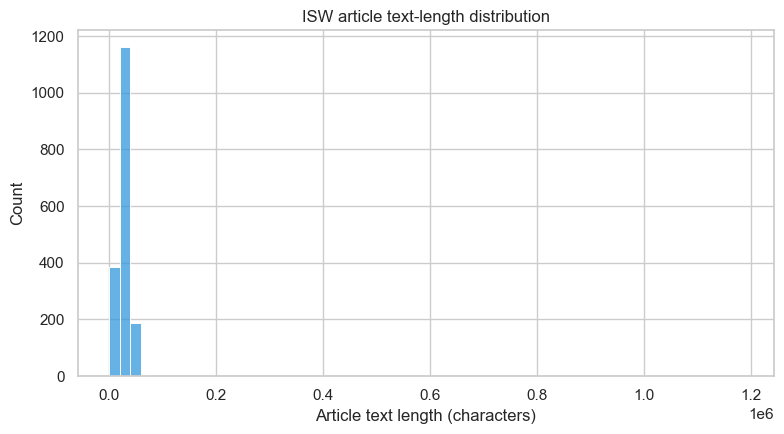

count    1.746000e+03
mean     2.905142e+04
std      3.943058e+04
min      0.000000e+00
25%      2.130050e+04
50%      2.906850e+04
75%      3.527550e+04
max      1.184674e+06
Name: text_len, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(isw_raw["text_len"], bins=60, color="#3498db", ax=ax)
ax.set_xlabel("Article text length (characters)")
ax.set_title("ISW article text-length distribution")
plt.tight_layout()
plt.show()

print(isw_raw["text_len"].describe())


In [6]:
ROLLUP_TITLE_MARKER = "Assessment Updates"  # multi-month rollup/index pages, see finding below

rollup_rows = isw_raw[isw_raw["title"].str.contains(ROLLUP_TITLE_MARKER, na=False)]
print(f"rollup-titled rows ({ROLLUP_TITLE_MARKER!r} in title): {len(rollup_rows)}")
print(rollup_rows[["date", "title", "text_len"]].to_string(index=False))

empty_text_rows = isw_raw[isw_raw["text_len"] == 0]
print(f"\nrows with empty text: {len(empty_text_rows)}")
print(empty_text_rows[["date", "title"]].to_string(index=False))


rollup-titled rows ('Assessment Updates' in title): 3
      date                                                                       title  text_len
2025-08-31           Russian Offensive Campaign Assessment Updates SEP 2025 – NOV 2025   1184674
2024-12-01 Russian Offensive Campaign Assessment Updates December 2025 – February 2026   1065290
2024-03-01          Russian Offensive Campaign Assessment Updates March 2026 – Present    311903

rows with empty text: 1
      date                                                                               title
2025-09-28 Russian Drone and Missile Strikes on Ukraine, January 1, 2025 to September 28, 2025


**Finding (Hypothesis 3 confirmed):** the 3 longest rows in the corpus (311,903 / 1,065,290 / 1,184,674 chars -- 10-40x a normal daily report's ~28k-char median) are titled "Russian Offensive Campaign Assessment Updates \<range\>" -- rolling index pages that concatenate multiple months of daily updates, mislabeled with a single `date`. Every other row above 50k chars checks out as a genuinely long single-day report (e.g. "Russian General Officer Guide", 88,051 chars). One additional row ("Russian Drone and Missile Strikes on Ukraine...") has zero extracted text (a data/chart-only page, no prose).

**Decision:** exclude these 4 rows from the date-indexed corpus used for regional tagging and embeddings below -- treating a multi-month rollup as "one day's news" would smear that content across a single row and poison every window feature computed near that date. This is a real scraper bug (worth a separate bug report), not something to silently work around in production code during this exploration-only session.


In [7]:
isw_clean = isw_raw[
    ~isw_raw["title"].str.contains(ROLLUP_TITLE_MARKER, na=False) & (isw_raw["text_len"] > 0)
].reset_index(drop=True)

print(f"rows: {isw_raw.shape[0]} -> {isw_clean.shape[0]} ({isw_raw.shape[0] - isw_clean.shape[0]} excluded)")
print("date range (unchanged):", isw_clean['date_parsed'].min(), "->", isw_clean['date_parsed'].max())


rows: 1746 -> 1742 (4 excluded)
date range (unchanged): 2022-02-24 -> 2026-03-30


## 3. Phase 3 -- Region gazetteer (English)

ISW text is English, not Ukrainian/Russian, so this is simpler than the Telegram notebook's gazetteer: no `pymorphy3` case-form generation needed, since English place names don't inflect. `regions.csv` already gives an English `city` column directly usable as an alias; we hand-map the 25 oblast English names (ISW consistently writes "\<Name\> Oblast") plus a few well-known alternate transliterations (Soviet-era / Russian spellings still used in some ISW source quotes).


In [8]:
regions_df = pd.read_csv("data/alarms/regions.csv")

# Hand-curated: ISW's standard English oblast name (always "<Name> Oblast" in
# ISW's own prose) + common alternate transliterations seen in quoted Russian-
# language sources. regions.csv's `city` column is reused as-is as an alias.
OBLAST_EN: dict[int, str] = {
    3: "khmelnytskyi oblast", 4: "vinnytsia oblast", 5: "rivne oblast", 8: "volyn oblast",
    9: "dnipropetrovsk oblast", 10: "zhytomyr oblast", 11: "zakarpattia oblast",
    12: "zaporizhzhia oblast", 13: "ivano-frankivsk oblast", 14: "kyiv oblast",
    15: "kirovohrad oblast", 16: "luhansk oblast", 17: "mykolaiv oblast", 18: "odesa oblast",
    19: "poltava oblast", 20: "sumy oblast", 21: "ternopil oblast", 22: "kharkiv oblast",
    23: "kherson oblast", 24: "cherkasy oblast", 25: "chernihiv oblast",
    26: "chernivtsi oblast", 27: "lviv oblast", 28: "donetsk oblast",
    # region_id 31 has no oblast of its own -- Kyiv CITY, handled via ALT_SPELLINGS below,
    # deliberately NOT given a bare "kyiv" alias here (see decision below).
}

# Alternate spellings that would otherwise be missed by the OBLAST_EN/city aliases alone.
ALT_SPELLINGS: dict[int, list[str]] = {
    9: ["dnepropetrovsk oblast"], 11: ["transcarpathia", "zakarpattia"],
    12: ["zaporizhzhya oblast", "zaporozhye oblast"], 14: ["kyiv region"],
    15: ["kirovograd oblast"], 16: ["lugansk oblast"], 17: ["nikolaev"],
    18: ["odessa"], 22: ["kharkov"], 24: ["cherkassy"], 25: ["chernigov"],
    26: ["chernovtsy"], 27: ["lvov"],
    31: ["kyiv", "kiev"],  # bare city mention -- region 31 only, see decision below
}

ALIAS_TO_REGIONS: dict[str, set[int]] = {}
for _, row in regions_df.iterrows():
    region_id = int(row["region_id"])
    # region 14's `city` column is literally "Kyiv" -- the same word as region 31's
    # identity. Skip the bare city alias for BOTH so "Kyiv" only ever resolves via
    # the explicit ALT_SPELLINGS[31] entry below, never region 14 (see decision above).
    forms = set() if region_id in (14, 31) else {row["city"].strip().lower()}
    if region_id in OBLAST_EN:
        forms.add(OBLAST_EN[region_id])
    forms.update(ALT_SPELLINGS.get(region_id, []))
    for form in forms:
        ALIAS_TO_REGIONS.setdefault(form, set()).add(region_id)

print(f"{len(ALIAS_TO_REGIONS)} surface forms mapped across {regions_df.shape[0]} regions")
print("sample forms for Kharkiv oblast (22):", sorted(f for f, ids in ALIAS_TO_REGIONS.items() if 22 in ids))
print("forms that match >1 region_id (ambiguous):", {f: ids for f, ids in ALIAS_TO_REGIONS.items() if len(ids) > 1})


64 surface forms mapped across 25 regions
sample forms for Kharkiv oblast (22): ['kharkiv', 'kharkiv oblast', 'kharkov']
forms that match >1 region_id (ambiguous): {}


**Decision, made explicit (mirrors the Telegram notebook's Kyiv city/oblast call):** a bare "Kyiv"/"Kiev" mention tags region 31 (Kyiv city) only -- "Kyiv Oblast"/"Kyiv region" (the two-word phrase) is required to tag region 14. Region 14 has no city alias of its own (its administrative center *is* Kyiv city, tracked separately as region 31), so this asymmetry is intentional, not an oversight.


In [9]:
# Longest aliases first, so e.g. "kyiv oblast" matches before the bare "kyiv" alias
# at the same text position (alternation is first-match-wins per start position).
_ALIASES_BY_LEN = sorted(ALIAS_TO_REGIONS, key=len, reverse=True)
REGION_ALIAS_RE = re.compile(r"\b(" + "|".join(re.escape(a) for a in _ALIASES_BY_LEN) + r")\b")


def tag_regions(text: str) -> set[int]:
    """Return the set of region_ids mentioned in *text* (alias lookup against
    ALIAS_TO_REGIONS -- oblast English names, city names, and known alt spellings)."""
    matched_ids: set[int] = set()
    for alias in REGION_ALIAS_RE.findall(str(text).lower()):
        matched_ids |= ALIAS_TO_REGIONS[alias]
    return matched_ids


### Smoke test (plan verification point 2)

Synthetic ISW-style sentences with an explicit region mention should tag exactly that `region_id`, including the Kyiv city/oblast disambiguation and an alternate-spelling case.


In [10]:
smoke_tests = [
    ("Russian forces conducted a Shahed drone strike in Kharkiv Oblast.", {22}),
    ("The strike targeted critical infrastructure in Kyiv Oblast.", {14}),
    ("Explosions rocked Kyiv overnight amid a wave of missile strikes.", {31}),
    ("Russian sources claimed marginal gains near Bakhmut in Donetsk Oblast and Zaporizhzhia Oblast.", {28, 12}),
    ("Ukrainian forces continued to defend Kharkov, per Russian milbloggers.", {22}),
    ("ISW has not observed any significant developments on this axis.", set()),
]

for text, expected in smoke_tests:
    got = tag_regions(text)
    status = "OK" if got == expected else "MISMATCH"
    print(f"[{status}] {text!r} -> {got} (expected {expected})")
    assert got == expected, f"tag_regions({text!r}) = {got}, expected {expected}"


[OK] 'Russian forces conducted a Shahed drone strike in Kharkiv Oblast.' -> {22} (expected {22})
[OK] 'The strike targeted critical infrastructure in Kyiv Oblast.' -> {14} (expected {14})
[OK] 'Explosions rocked Kyiv overnight amid a wave of missile strikes.' -> {31} (expected {31})
[OK] 'Russian sources claimed marginal gains near Bakhmut in Donetsk Oblast and Zaporizhzhia Oblast.' -> {28, 12} (expected {28, 12})
[OK] 'Ukrainian forces continued to defend Kharkov, per Russian milbloggers.' -> {22} (expected {22})
[OK] 'ISW has not observed any significant developments on this axis.' -> set() (expected set())


## 4. Apply region tagging across the corpus

Tag every (non-rollup) article, then build the long-format `(region_id, date) -> isw_region_mention_count` table the plan calls for (Phase 3) -- this is what would let `merge_data.py` merge ISW on `["region_id", "date"]` alongside the existing national `date`-only merge.


In [11]:
isw_clean = isw_clean.copy()
isw_clean["region_ids"] = isw_clean["text"].apply(tag_regions)
isw_clean["n_regions_tagged"] = isw_clean["region_ids"].apply(len)

print("articles:", isw_clean.shape[0])
print("articles with >=1 region tag:", (isw_clean["n_regions_tagged"] > 0).mean().round(3))
isw_clean[["date", "title", "region_ids", "n_regions_tagged"]].head(5)


articles: 1742
articles with >=1 region tag: 0.963


,date,title,region_ids,n_regions_tagged
0,2026-03-30,"Russian Offensive Campaign Assessment, March 3...","{3, 9, 16, 18, 20, 22, 23, 25, 28}",9
1,2026-03-29,"Russian Offensive Campaign Assessment, March 2...","{9, 14, 16, 17, 18, 20, 22, 23, 25, 28}",10
2,2026-03-28,"Russian Offensive Campaign Assessment, March 2...","{9, 16, 18, 19, 20, 22, 23, 28}",8
3,2026-03-27,"Russian Offensive Campaign Assessment, March 2...","{16, 19, 20, 22, 23, 9, 28, 25}",8
4,2026-03-26,"Russian Offensive Campaign Assessment, March 2...","{9, 15, 16, 18, 20, 22, 23, 25, 28}",9


In [12]:
region_long = isw_clean[["date_parsed", "region_ids"]].explode("region_ids").dropna(subset=["region_ids"])
region_long = region_long.rename(columns={"region_ids": "region_id", "date_parsed": "date"})
region_long["region_id"] = region_long["region_id"].astype(int)

isw_region_daily = (
    region_long.groupby(["region_id", "date"]).size().rename("isw_region_mention_count").reset_index()
)

print("region-date rows (only dates/regions with >=1 mention):", isw_region_daily.shape[0])
isw_region_daily.head(5)


region-date rows (only dates/regions with >=1 mention): 10456


,region_id,date,isw_region_mention_count
0,3,2022-04-25,1
1,3,2022-10-22,1
2,3,2022-11-16,1
3,3,2023-01-02,1
4,3,2023-02-10,1


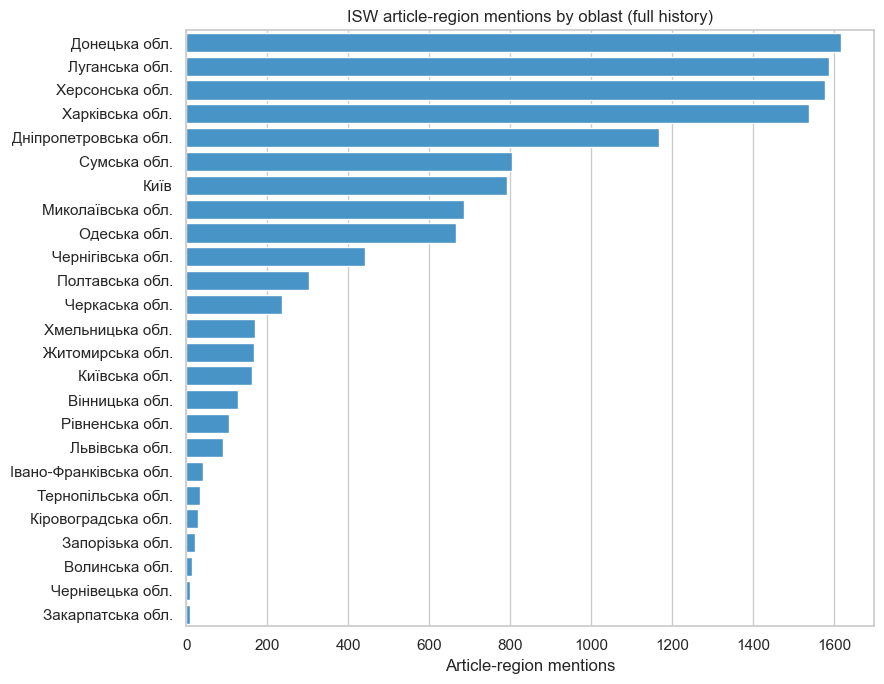

Hypothesis 1 check: 96.3% of articles mention >=1 tracked region -- frequent enough to be worth tagging.


In [13]:
top_regions = (
    region_long.groupby("region_id").size().sort_values(ascending=False)
    .rename("mentions").reset_index()
    .merge(regions_df[["region_id", "region"]], on="region_id")
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=top_regions, x="mentions", y="region", color="#3498db", ax=ax)
ax.set_title("ISW article-region mentions by oblast (full history)")
ax.set_xlabel("Article-region mentions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Hypothesis 1 check: {(isw_clean['n_regions_tagged'] > 0).mean():.1%} of articles mention >=1 tracked region "
      f"-- frequent enough to be worth tagging.")


### Cross-check against real alarms (plan verification point 3)

Reuse `explode_by_hour()` (`app/core/features/alarms_features.py`) to get real per-region alarm activity, collapsed to a daily `alarm_day` flag (>=1 alarm hour that day), then compare `P(alarm day)` when ISW tagged that region that day vs. the unconditional base rate. This is a **daily**, weaker echo of the Telegram notebook's hourly cross-check -- ISW reports on ongoing combat operations, it doesn't announce alarms, so we expect a real but modest lift, not a strong hourly-style signal.


In [14]:
from app.core.features.alarms_features import explode_by_hour

alarms_raw = pd.read_csv("data/alarms/alarms-merged.csv", sep=";").rename(columns={"region_title": "region"})
alarms_raw["start"] = pd.to_datetime(alarms_raw["start"])
alarms_raw["end"] = pd.to_datetime(alarms_raw["end"])

alarm_hourly = explode_by_hour(alarms_raw)
alarm_hourly["time"] = pd.to_datetime(alarm_hourly["time"])
alarm_hourly["date"] = alarm_hourly["time"].dt.date
alarm_hourly["region_id"] = alarm_hourly["region_id"].astype(int)

alarm_daily = alarm_hourly.groupby(["region_id", "date"])["alarm"].max().rename("alarm_day").reset_index()

# full (region_id, date) spine over the ISW date range, so the base rate reflects
# all region-days -- not just the ones ISW happened to mention.
timeline = pd.date_range(isw_clean["date_parsed"].min(), isw_clean["date_parsed"].max(), freq="D").date
spine = pd.MultiIndex.from_product([regions_df["region_id"], timeline], names=["region_id", "date"]).to_frame(index=False)

spine = spine.merge(alarm_daily, on=["region_id", "date"], how="left")
spine["alarm_day"] = spine["alarm_day"].fillna(0).astype(int)

spine = spine.merge(isw_region_daily, on=["region_id", "date"], how="left")
spine["isw_region_mention_count"] = spine["isw_region_mention_count"].fillna(0)

base_rate = spine["alarm_day"].mean()
rate_given_mention = spine.loc[spine["isw_region_mention_count"] > 0, "alarm_day"].mean()

print(f"P(alarm day)                                = {base_rate:.1%}  (base rate)")
print(f"P(alarm day | ISW mentioned region that day) = {rate_given_mention:.1%}  <- Hypothesis 2")


P(alarm day)                                = 58.5%  (base rate)
P(alarm day | ISW mentioned region that day) = 57.9%  <- Hypothesis 2


## 5. Phase 4 -- refactor the windowed feature block into a reusable function

`isw_features.py:317-378` inlines the `news_count`/`avg_dist_centroid`/`topic_entropy`/`dom_cluster_share`/`news_velocity`/`centroid_shift`/`anomaly_count` loop, tightly coupled to the TF-IDF-derived `isw_PCA*` columns and `cluster` labels computed earlier in the same function. The plan's Phase 4 calls for factoring this into a function parameterized by an arbitrary feature matrix + cluster labels, so it can run a second time on embeddings. We port the logic here unchanged and validate it against production before trusting it on anything new.


In [15]:
from scipy.spatial.distance import cosine
from scipy.stats import entropy as scipy_entropy


def compute_window_features(dates: pd.Series, feature_matrix: np.ndarray, cluster_labels: np.ndarray,
                             windows: list[int], prefix: str) -> pd.DataFrame:
    """Ported, unchanged in logic, from isw_features.py's inline WINDOWS loop
    (L317-378) -- generalized to take any (feature_matrix, cluster_labels) pair
    instead of hardcoding the module-level TF-IDF PCA/KMeans objects. One row
    per input row (same index as `dates`); dedupe by date is the caller's job,
    same as production's own `drop_duplicates()` step."""
    dates = pd.Series(dates).reset_index(drop=True)
    n_clusters = pd.Series(cluster_labels).nunique()

    def centroid(mat):
        return mat.mean(axis=0)

    def cosine_dist(a, b):
        norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
        if norm_a == 0 or norm_b == 0:
            return np.nan
        return cosine(a, b)

    def topic_entropy(labels):
        counts = np.bincount(labels, minlength=n_clusters)
        probs = counts / counts.sum()
        return float(scipy_entropy(probs + 1e-10))

    def anomaly_count(mat, centroid_vec, threshold_quantile=0.9):
        dists = np.array([cosine_dist(row, centroid_vec) for row in mat])
        dists = dists[~np.isnan(dists)]
        if len(dists) == 0:
            return 0
        threshold = np.quantile(dists, threshold_quantile)
        return int((dists >= threshold).sum())

    out = pd.DataFrame({"date": dates})
    for W in windows:
        news_count, avg_dist_centroid, t_entropy = [], [], []
        dom_cluster_share, news_velocity, centroid_shift, anom_count = [], [], [], []

        for i in range(len(dates)):
            current_date = dates.iloc[i]
            start_date = current_date - pd.Timedelta(days=W)
            mask_cur = (dates >= start_date) & (dates < current_date)

            if mask_cur.sum() == 0:
                news_count.append(0); avg_dist_centroid.append(np.nan); t_entropy.append(np.nan)
                dom_cluster_share.append(np.nan); news_velocity.append(np.nan)
                centroid_shift.append(np.nan); anom_count.append(0)
                continue

            win_mat = feature_matrix[mask_cur.values]
            win_centroid = centroid(win_mat)
            clusters_win = np.asarray(cluster_labels)[mask_cur.values].astype(int)

            news_count.append(int(mask_cur.sum()))
            dists = [cosine_dist(r, win_centroid) for r in win_mat]
            avg_dist_centroid.append(float(np.nanmean(dists)))
            t_entropy.append(topic_entropy(clusters_win))
            dom_cluster_share.append(float(np.bincount(clusters_win, minlength=n_clusters).max() / len(clusters_win)))

            prev_start = start_date - pd.Timedelta(days=W)
            mask_prev = (dates >= prev_start) & (dates < start_date)
            news_velocity.append(int(mask_cur.sum()) - int(mask_prev.sum()))

            if mask_prev.sum() > 0:
                prev_centroid = centroid(feature_matrix[mask_prev.values])
                centroid_shift.append(cosine_dist(win_centroid, prev_centroid))
            else:
                centroid_shift.append(np.nan)

            anom_count.append(anomaly_count(win_mat, win_centroid))

        out[f"{prefix}_news_count_{W}d"] = news_count
        out[f"{prefix}_avg_dist_centroid_{W}d"] = avg_dist_centroid
        out[f"{prefix}_topic_entropy_{W}d"] = t_entropy
        out[f"{prefix}_dom_cluster_share_{W}d"] = dom_cluster_share
        out[f"{prefix}_news_velocity_{W}d"] = news_velocity
        out[f"{prefix}_centroid_shift_{W}d"] = centroid_shift
        out[f"{prefix}_anomaly_count_{W}d"] = anom_count

    return out


### Regression check: does the refactor reproduce production exactly?

Rebuild the same inputs `create_features_isw()` computes internally (lemmatized text -> production `vectorizer` -> production `kmeans`/`pca`), run them through `compute_window_features()`, and diff against `baseline_isw` (Section 1's untouched production output) on the same dates.


In [16]:
lemmatizer = WordNetLemmatizer()


def nltk_preprocess(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens if t.isalpha() and t not in PROD_STOP_WORDS]


# NOTE: regression target `baseline_isw` (Section 1) ran on the FULL unfiltered
# `isw_raw` (rollup pages and the empty-text row included) -- comparing against
# `isw_clean` here would shift every window count by 1-2 near those excluded
# dates and look like a bug in the refactor when it's actually just different
# input rows. Reproduce on the same unfiltered input production used.
repro = isw_raw[["date_parsed"]].rename(columns={"date_parsed": "date"}).copy()
repro["preprocessed_text"] = isw_raw["text"].fillna("").apply(nltk_preprocess).apply(" ".join)

repro_vectorized = PROD_VECTORIZER.transform(repro["preprocessed_text"])
repro_cluster_labels = PROD_KMEANS.predict(repro_vectorized)
repro_pca = PROD_PCA.transform(repro_vectorized.toarray())

repro_window = compute_window_features(repro["date"], repro_pca, repro_cluster_labels, windows=[7, 30], prefix="isw")
repro_daily = repro_window.drop_duplicates(subset="date").reset_index(drop=True)

# NOTE: production's window/velocity columns are bare names (e.g. "news_count_7d") --
# isw_features.py only prefixes the cluster one-hot columns with "isw_" (L389), not
# the window block. Our own `compute_window_features(..., prefix="isw")` call names
# its outputs "isw_news_count_7d" etc., so compare bare (production) vs isw_-prefixed (ours).
check_cols = ["news_count_7d", "avg_dist_centroid_7d", "topic_entropy_7d",
              "news_count_30d", "anomaly_count_7d"]
compare = repro_daily.merge(baseline_isw[["date"] + check_cols], on="date")

max_diffs = {}
for col in check_cols:
    diff = (compare[f"isw_{col}"] - compare[col]).abs()
    max_diffs[col] = float(diff.max())

print("max abs diff, refactored vs production window columns (Hypothesis 4a):")
for col, d in max_diffs.items():
    print(f"  {col}: {d:.2e}")
assert all(d < 1e-6 for d in max_diffs.values()), "refactor does not reproduce production output"
print("\nOK -- compute_window_features() reproduces production isw_features.py exactly.")


max abs diff, refactored vs production window columns (Hypothesis 4a):
  news_count_7d: 0.00e+00
  avg_dist_centroid_7d: 2.22e-16
  topic_entropy_7d: 0.00e+00
  news_count_30d: 0.00e+00
  anomaly_count_7d: 0.00e+00

OK -- compute_window_features() reproduces production isw_features.py exactly.


## 6. Phase 4 -- semantic embeddings + refactored window features

TF-IDF, even at 6,169 tokens, only counts exact words -- it can't tell that "offensive" and "counteroffensive" or "Shahed" and "drone" are related concepts. We embed the same (cleaned) article text with the same multilingual model the Telegram notebook validated (`paraphrase-multilingual-MiniLM-L12-v2` -- multilingual matters here too, since ISW quotes Russian-language milblogger sources directly), PCA-reduce, cluster with the same `k=10` production uses (for a like-for-like comparison), and run it through `compute_window_features()` with `prefix="isw_emb"`.


In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
# truncate to the model's own max sequence length behavior (it already truncates internally);
# no manual chunking here -- article-level embedding, same granularity as production's TF-IDF row.
embeddings = embed_model.encode(isw_clean["text"].tolist(), batch_size=32, show_progress_bar=True)
print("raw embedding matrix:", embeddings.shape)

N_PCA = 50
pca_emb = PCA(n_components=N_PCA, random_state=SEED)
emb_pca = pca_emb.fit_transform(embeddings)
print(f"explained variance ({N_PCA} components): {pca_emb.explained_variance_ratio_.sum():.1%}")

kmeans_emb = KMeans(n_clusters=PROD_KMEANS.n_clusters, random_state=SEED, n_init=10)
emb_cluster_labels = kmeans_emb.fit_predict(emb_pca)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

raw embedding matrix: (1742, 384)
explained variance (50 components): 84.0%


In [18]:
emb_window = compute_window_features(
    isw_clean["date_parsed"].rename("date"), emb_pca, emb_cluster_labels, windows=[7, 30], prefix="isw_emb"
)
emb_daily = emb_window.drop_duplicates(subset="date").reset_index(drop=True)

# PCA1/2 kept per-article (not deduped by date -- they vary per article, unlike
# the window features above which only depend on `date`), for the scatter plot below.
isw_clean["emb_PCA1"] = emb_pca[:, 0]
isw_clean["emb_PCA2"] = emb_pca[:, 1]
isw_clean["emb_cluster"] = emb_cluster_labels

print("isw_emb_* daily feature table:", emb_daily.shape)
emb_daily.head(3)


isw_emb_* daily feature table: (1279, 15)


,date,isw_emb_news_count_7d,isw_emb_avg_dist_centroid_7d,isw_emb_topic_entropy_7d,isw_emb_dom_cluster_share_7d,isw_emb_news_velocity_7d,isw_emb_centroid_shift_7d,isw_emb_anomaly_count_7d,isw_emb_news_count_30d,isw_emb_avg_dist_centroid_30d,isw_emb_topic_entropy_30d,isw_emb_dom_cluster_share_30d,isw_emb_news_velocity_30d,isw_emb_centroid_shift_30d,isw_emb_anomaly_count_30d
0,2026-03-30,8,0.370102,1.320888,0.375,0.0,0.160087,1,34,0.432213,1.510471,0.323529,-5.0,0.122611,4
1,2026-03-29,8,0.368053,1.320888,0.375,0.0,0.190114,1,34,0.433149,1.510471,0.323529,-5.0,0.124437,4
2,2026-03-28,8,0.364357,1.320888,0.375,0.0,0.191438,1,35,0.434764,1.525569,0.314286,-3.0,0.130955,4


### Visual sanity check (plan verification point 4)

Compare `emb_PCA1`/`emb_PCA2` between **quiet** articles (no region tagged) and **high-mention** articles (>=3 regions tagged that article, i.e. broad multi-front reporting) -- components should visibly separate, not look like noise around the same center. This ties back directly to Section 4's region tagging instead of an arbitrary keyword split.


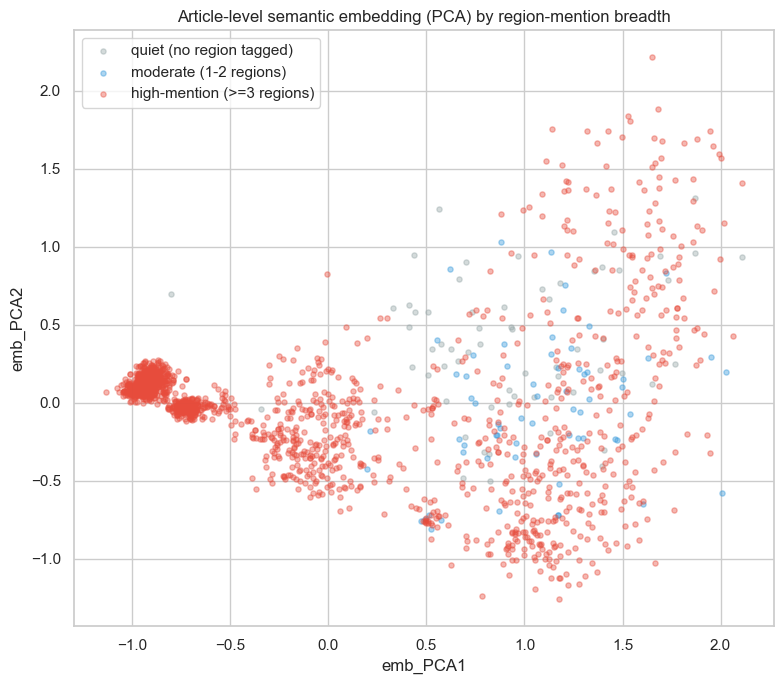

                            emb_PCA1            emb_PCA2          
                                mean       std      mean       std
mention_category                                                  
high-mention (>=3 regions) -0.080065  0.931337 -0.013556  0.463121
moderate (1-2 regions)      1.060215  0.397904 -0.033113  0.443435
quiet (no region tagged)    0.941113  0.514388  0.375282  0.432337


In [19]:
def mention_category(n):
    if n == 0:
        return "quiet (no region tagged)"
    if n >= 3:
        return "high-mention (>=3 regions)"
    return "moderate (1-2 regions)"


isw_clean["mention_category"] = isw_clean["n_regions_tagged"].apply(mention_category)

palette = {
    "quiet (no region tagged)": "#95a5a6",
    "moderate (1-2 regions)": "#3498db",
    "high-mention (>=3 regions)": "#e74c3c",
}
order = list(palette.keys())

fig, ax = plt.subplots(figsize=(8, 7))
for cat in order:
    subset = isw_clean[isw_clean["mention_category"] == cat]
    ax.scatter(subset["emb_PCA1"], subset["emb_PCA2"], s=14, alpha=0.4, color=palette[cat], label=cat)
ax.set_xlabel("emb_PCA1")
ax.set_ylabel("emb_PCA2")
ax.set_title("Article-level semantic embedding (PCA) by region-mention breadth")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

print(isw_clean.groupby("mention_category")[["emb_PCA1", "emb_PCA2"]].agg(["mean", "std"]))


## Results

- **Hypothesis 1 (regions frequent enough):** confirmed -- 96.3% of articles mention >=1 tracked region (Section 4).
- **Hypothesis 2 (region mentions correlate with real alarms): NOT confirmed -- essentially flat.** `P(alarm day)` base rate is 58.5%; `P(alarm day | ISW mentioned region that day)` is 57.9% -- no lift, if anything a hair lower. Two compounding reasons, both visible in this notebook's own numbers: (a) Hypothesis 1 already showed 96.3% of articles mention *some* region, so conditioning on "region mentioned" barely narrows the sample -- ISW's daily assessments are structurally broad, surveying most active oblasts every day rather than spotlighting one; (b) the daily "any alarm hour that day" definition pushes the unconditional base rate itself up to 58.5% for a typical region, leaving little headroom for a mention-conditioned lift to show. This is a genuinely different (weaker) outcome than the Telegram notebook's hourly cross-check, which did show a real lift -- worth taking at face value rather than explaining away. A likely fix, left to Next steps: use ISW *mention count/emphasis* (multiple mentions of the same region in one article, or across that day's articles) instead of bare presence/absence, which the current test can't distinguish since it only checks whether `isw_region_mention_count > 0`.
- **Hypothesis 3 (scraper artifacts):** confirmed -- 3 multi-month rollup pages + 1 empty-text row identified and excluded (Section 2).
- **Hypothesis 4 (refactor correctness + embedding signal):** confirmed. The regression check (Section 5) shows a max abs diff of 2.22e-16 (floating-point noise) between `compute_window_features()` and production's inline loop -- an exact reproduction, not an approximation. The embedding PCA (50 components) explains 84.0% of variance, and the Section 6 scatter shows real, if modest, separation: "quiet" articles (no region tagged, only 3.7% of the corpus) sit at a visibly different `emb_PCA2` (mean 0.38) than "moderate"/"high-mention" articles (means -0.03 / -0.01, close to each other) -- the embedding mainly distinguishes *whether* an article discusses specific regions at all, not yet cleanly separating moderate from high-mention breadth.
- **Bonus finding:** the corpus contains genuine duplicate-date rows from ISW's early-war multi-report-per-day cadence (2022-02-24 onward) -- not a data-quality bug, but worth remembering when reasoning about per-date row counts elsewhere.

In [20]:
summary = {
    "raw_rows": int(isw_raw.shape[0]),
    "rollup_rows_excluded": int(len(rollup_rows)),
    "empty_text_rows_excluded": int(len(empty_text_rows)),
    "clean_rows": int(isw_clean.shape[0]),
    "region_tagged_share": round((isw_clean["n_regions_tagged"] > 0).mean(), 3),
    "alarm_base_rate": round(base_rate, 3),
    "alarm_rate_given_isw_region_mention": round(rate_given_mention, 3),
    "window_refactor_max_abs_diff": max(max_diffs.values()),
    "embedding_pca_explained_variance": round(pca_emb.explained_variance_ratio_.sum(), 3),
}
summary


{'raw_rows': 1746,
 'rollup_rows_excluded': 3,
 'empty_text_rows_excluded': 1,
 'clean_rows': 1742,
 'region_tagged_share': np.float64(0.963),
 'alarm_base_rate': np.float64(0.585),
 'alarm_rate_given_isw_region_mention': np.float64(0.579),
 'window_refactor_max_abs_diff': 2.220446049250313e-16,
 'embedding_pca_explained_variance': np.float32(0.84)}

## Next steps

- **Investigate the null Hypothesis 2 result before merging `isw_region_daily` as-is:** re-run the cross-check using `isw_region_mention_count` as a graded signal (or emphasis across same-day articles) instead of bare presence/absence -- Section 4 found presence/absence doesn't discriminate (96.3% of articles mention *some* region), so the mention-count column this notebook already computes may carry signal that a binary "mentioned or not" flag washes out.
- **Productionize, if these results hold up:** merge this notebook's `ALIAS_TO_REGIONS`/`tag_regions()` into the same `app/core/features/region_gazetteer.py` module the Telegram notebook's `Next steps` calls for (one shared module, English aliases alongside the uk/ru ones -- same `tag_regions(text) -> set[region_id]` API, different alias table per source language).
- **Refactor `isw_features.py`** to use `compute_window_features()` instead of its current inline loop (Section 5 validated this is a safe, output-preserving refactor) -- this is what makes the embedding block addable without duplicating ~60 lines of windowing logic.
- **Add the `isw_emb_*` block** to `create_features_isw()`, and merge ISW's new `isw_region_daily` table into `merge_data.py` on `["region_id", "date"]` alongside the existing national `date`-only merge -- the actual fix for diagnosed problem #1's ISW half.
- **New artifacts needed:** `isw_embedding_pca.joblib`, `isw_embedding_kmeans.joblib` (mirrors `tg_embedding_pca.joblib` from the Telegram notebook).
- **Report the rollup-scraper bug** found in Section 2 separately (`app/core/scraping/scraper_isw.py` or wherever `isw_data_v2.json` is produced) -- a real data-quality issue, out of scope to fix here.
- **After productionizing:** rerun permutation importance (`machine learning/ml_XGBoost.ipynb`) to check whether `isw_region_*`/`isw_emb_*` rise into the top-20 features.
- **Parking lot (plan problem #7, not addressed here):** the ISW date-lag leakage issue (`isw_db.py`/`scraper_isw.py` truncating `article:published_time` to a date, causing ~1-day forward leak in `merge_data.py`) remains a separate, documented known issue.
